In [2]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.2 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 31.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\jijes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Cell 1 — Imports
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "../results"
PLOTS_DIR   = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [6]:
# Cell 2 — Load CSVs with model as index
memory_df     = pd.read_csv(f"{RESULTS_DIR}/memory_results.csv", index_col=0)
latency_df    = pd.read_csv(f"{RESULTS_DIR}/latency_results.csv")
throughput_df = pd.read_csv(f"{RESULTS_DIR}/throughput_results.csv")

print("Memory:\n", memory_df)
print("\nLatency:\n", latency_df.head())
print("\nThroughput:\n", throughput_df.head())

Memory:
       allocated   reserved  memory_allocated_for_2k_generation
fp16  16.060523  16.064184                           16.581880
int8   9.095276   9.175040                            9.676418
gptq   5.745206   5.758779                            7.197649
awq    5.737473   6.803161                            6.045553

Latency:
   model    phase  prompt_length  time_sec  tokens_per_sec  mem_allocated_gb  \
0  fp16  prefill            128  0.029544     4332.579502         16.119376   
1  fp16     ttft            128  0.029999             NaN               NaN   
2  fp16   decode            128  0.022979       43.517912         16.140348   
3  fp16  prefill            512  0.081079     6314.824203         16.268281   
4  fp16     ttft            512  0.076876             NaN               NaN   

   gpu_memory_util_pct  
0                 92.0  
1                  NaN  
2                100.0  
3                 40.0  
4                  NaN  

Throughput:
   model       phase  batch

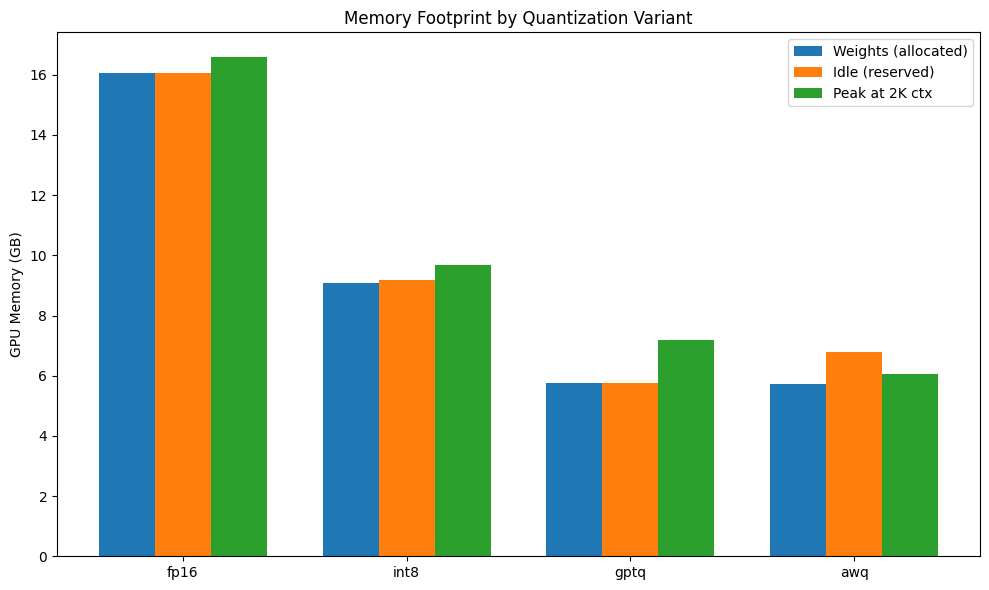

Saved memory_comparison.png


In [7]:
# Cell 3 — Memory bar chart
models   = memory_df.index.tolist()
x        = range(len(models))
width    = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width for i in x], memory_df["allocated"],                          width, label="Weights (allocated)")
ax.bar([i         for i in x], memory_df["reserved"],                           width, label="Idle (reserved)")
ax.bar([i + width for i in x], memory_df["memory_allocated_for_2k_generation"], width, label="Peak at 2K ctx")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("GPU Memory (GB)")
ax.set_title("Memory Footprint by Quantization Variant")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/memory_comparison.png", dpi=150)
plt.show()
print("Saved memory_comparison.png")

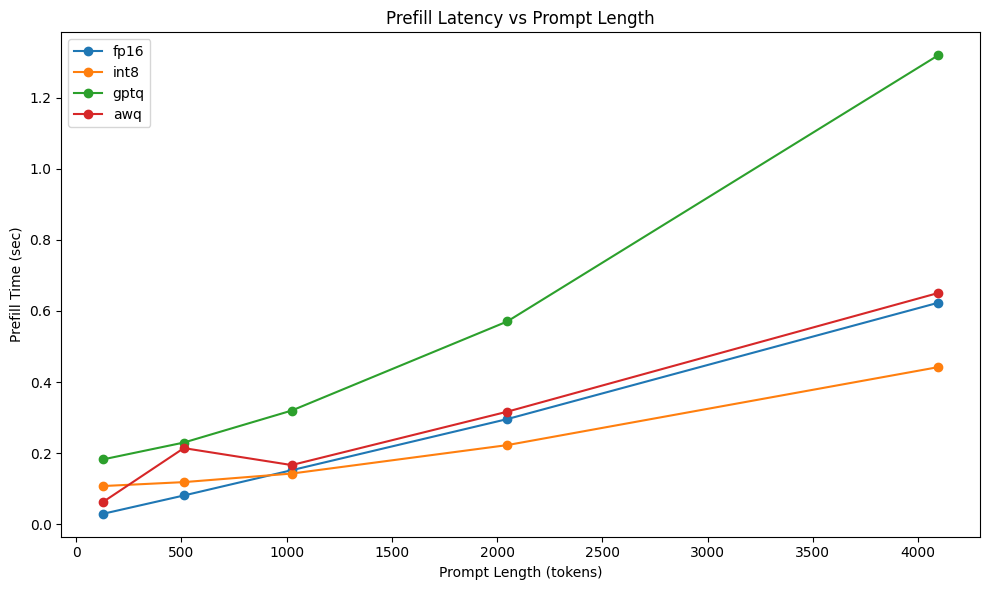

Saved prefill_latency.png


In [8]:
# Prefill latency line chart
# One line per model, x = prompt length, y = prefill time
prefill_df = latency_df[latency_df["phase"] == "prefill"]

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in prefill_df["model"].unique():
    subset = prefill_df[prefill_df["model"] == model_name]
    ax.plot(subset["prompt_length"], subset["time_sec"],
            marker="o", label=model_name)

ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("Prefill Time (sec)")
ax.set_title("Prefill Latency vs Prompt Length")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/prefill_latency.png", dpi=150)
plt.show()
print("Saved prefill_latency.png")

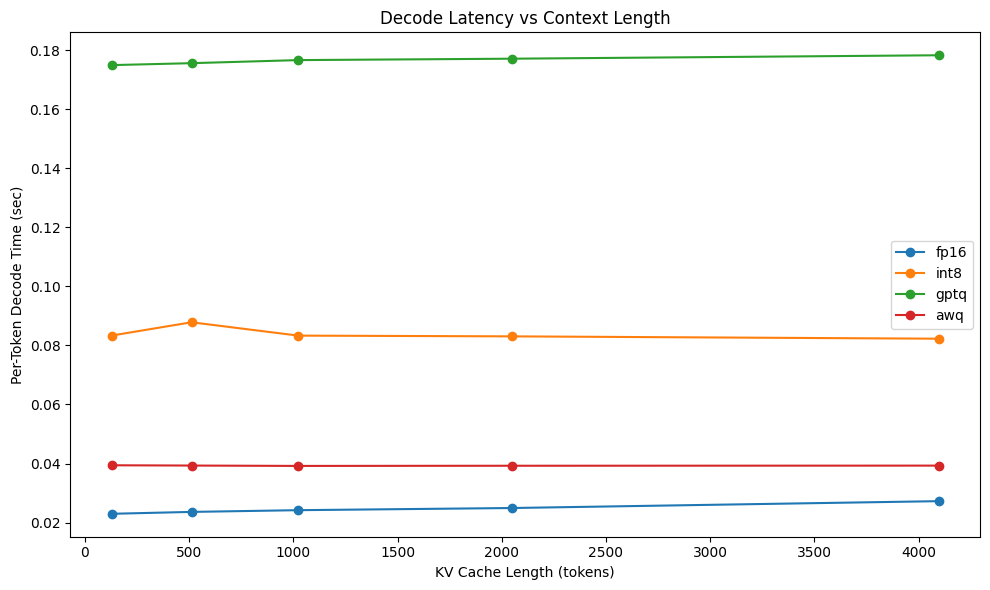

Saved decode_latency.png


In [9]:
# Decode latency line chart
# One line per model, x = prompt length, y = per-token decode time
decode_df = latency_df[latency_df["phase"] == "decode"]

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in decode_df["model"].unique():
    subset = decode_df[decode_df["model"] == model_name]
    ax.plot(subset["prompt_length"], subset["time_sec"],
            marker="o", label=model_name)

ax.set_xlabel("KV Cache Length (tokens)")
ax.set_ylabel("Per-Token Decode Time (sec)")
ax.set_title("Decode Latency vs Context Length")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/decode_latency.png", dpi=150)
plt.show()
print("Saved decode_latency.png")

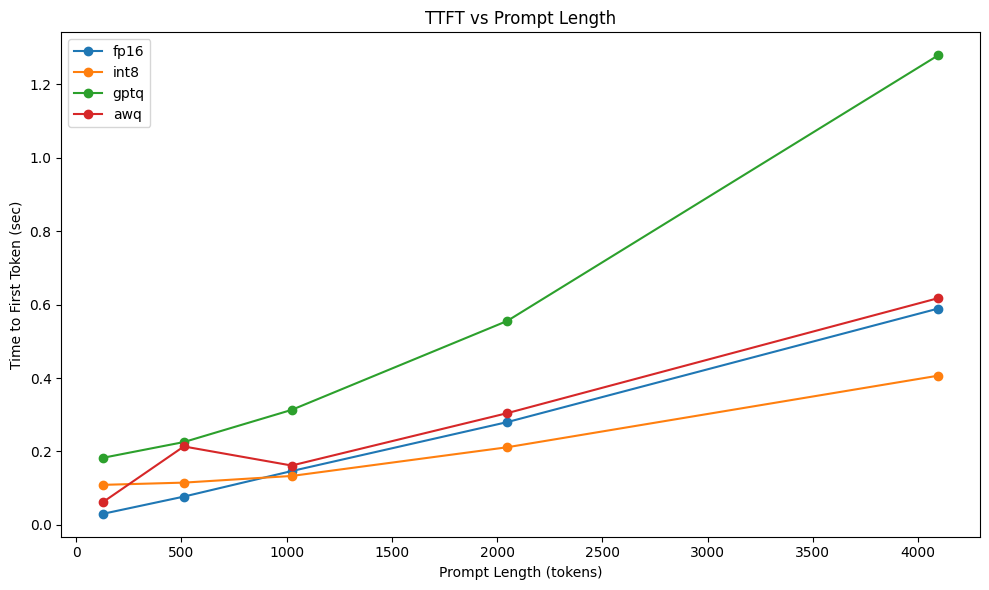

Saved ttft.png


In [10]:
# TTFT line chart
# Time to first token — one line per model, x = prompt length
ttft_df = latency_df[latency_df["phase"] == "ttft"]

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in ttft_df["model"].unique():
    subset = ttft_df[ttft_df["model"] == model_name]
    ax.plot(subset["prompt_length"], subset["time_sec"],
            marker="o", label=model_name)

ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("Time to First Token (sec)")
ax.set_title("TTFT vs Prompt Length")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/ttft.png", dpi=150)
plt.show()
print("Saved ttft.png")

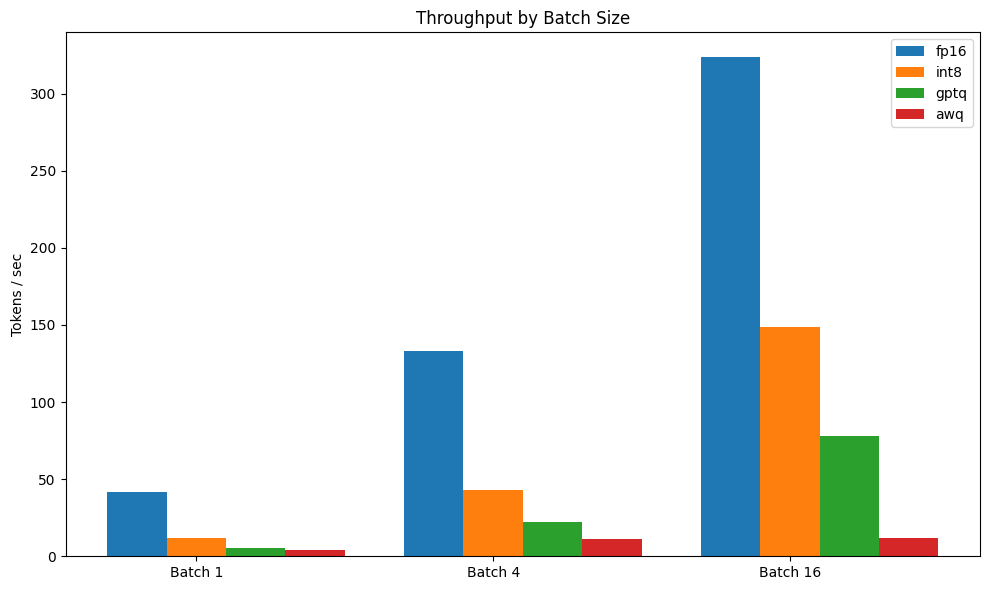

Saved throughput.png


In [11]:
# Throughput bar chart
# Grouped bars: batch size 1, 4, 16 for each model
tput_df = throughput_df[throughput_df["phase"] == "throughput"]

fig, ax = plt.subplots(figsize=(10, 6))
batch_sizes = sorted(tput_df["batch_size"].unique())
models      = tput_df["model"].unique()
width       = 0.2
x           = range(len(batch_sizes))

for i, model_name in enumerate(models):
    subset = tput_df[tput_df["model"] == model_name]
    subset = subset.sort_values("batch_size")
    ax.bar([j + i * width for j in x],
           subset["tokens_per_sec"],
           width, label=model_name)

ax.set_xticks([j + width for j in x])
ax.set_xticklabels([f"Batch {bs}" for bs in batch_sizes])
ax.set_ylabel("Tokens / sec")
ax.set_title("Throughput by Batch Size")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/throughput.png", dpi=150)
plt.show()
print("Saved throughput.png")

In [12]:
#OOM sweep table
# Shows max batch size each variant can handle at 2K context
oom_df = throughput_df[throughput_df["phase"] == "oom_sweep"]
print("\nOOM Sweep Results (2K context):")
print(oom_df[["model", "batch_size", "status"]].to_string(index=False))


OOM Sweep Results (2K context):
model  batch_size status
 fp16           1     ok
 fp16           2     ok
 fp16           4     ok
 fp16           8     ok
 fp16          16     ok
 fp16          32     ok
 int8           1     ok
 int8           2     ok
 int8           4     ok
 int8           8     ok
 int8          16     ok
 int8          32     ok
 gptq           1     ok
 gptq           2     ok
 gptq           4     ok
 gptq           8     ok
 gptq          16     ok
 gptq          32    OOM
  awq           1     ok
  awq           2     ok
  awq           4     ok
  awq           8     ok
  awq          16     ok
  awq          32     ok
